In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE 

# Set plot style for better visuals
sns.set(style="whitegrid")

print("Libraries imported successfully!")

# Load the dataset
try:
    # IMPORTANT: Ensure your CSV file is named 'Accidents.csv' or change the filename below
    df = pd.read_csv('Accidents.csv', low_memory=False)
    print("Dataset loaded successfully.")
    print(f"Dataset shape: {df.shape}")
except FileNotFoundError:
    print("Error: Accidents.csv not found. Please download the dataset and place it in the correct directory.")

# Display the first few rows to confirm it's loaded
df.head()

Libraries imported successfully!
Dataset loaded successfully.
Dataset shape: (50000, 34)


,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,...,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,201243N256052,C,87.0,NaN,NaN,Slight,NaN,2012-05-25,Friday,1.0,...,Thames Valley,Dry,Single carriageway,NaN,40.0,08:27,Rural,Fine no high winds,2012,No
1,200750B71P198,B,3254.0,NaN,0.0,Serious,NaN,2007-12-11,Tuesday,1.0,...,Devon and Cornwall,Wet or damp,Dual carriageway,NaN,60.0,16:15,Rural,Fine no high winds,2007,No
2,200601MM70553,A,2214.0,C,0.0,Slight,NaN,2006-07-03,Monday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,17:07,Urban,Fine no high winds,2006,No
3,200597UD20709,A,77.0,Unclassified,0.0,Slight,NaN,2005-09-17,Saturday,1.0,...,Strathclyde,Wet or damp,Single carriageway,NaN,60.0,16:10,Rural,Raining no high winds,2005,Yes
4,2016300019227,B,6013.0,Unclassified,0.0,Slight,NaN,2016-05-12,Thursday,1.0,...,Derbyshire,Dry,Single carriageway,NaN,30.0,14:50,Urban,Fine no high winds,2016,No


Missing values before cleaning:
Severity            0
Road_Conditions     0
Weather             0
Road_Type           0
Light_Conditions    0
Speed_Limit         1
Junction_Control    0
Num_Vehicles        0
Num_Casualties      0
Junction_Detail     0
Area_Type           0
Day_of_Week         0
Hour_of_Day         5
dtype: int64

Missing values after cleaning:
Severity            0
Road_Conditions     0
Weather             0
Road_Type           0
Light_Conditions    0
Speed_Limit         0
Junction_Control    0
Num_Vehicles        0
Num_Casualties      0
Junction_Detail     0
Area_Type           0
Day_of_Week         0
Hour_of_Day         0
dtype: int64

Shape of cleaned data: (49994, 13)


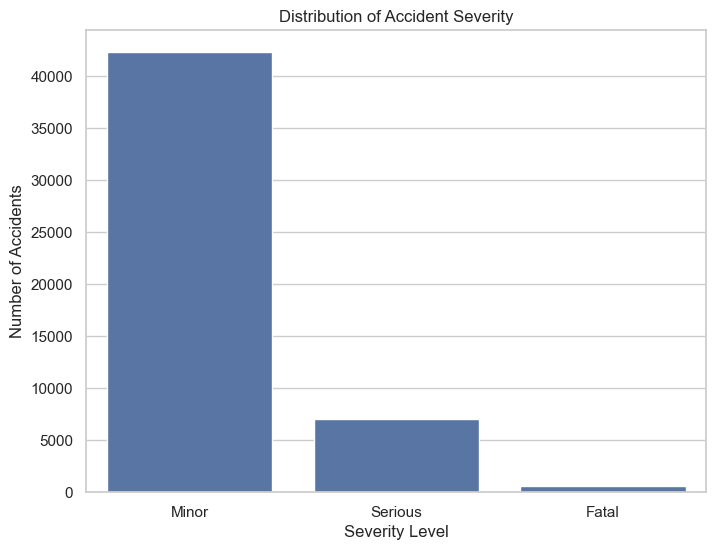


Severity Value Counts (Corrected):
Severity
Minor      42327
Serious     7061
Fatal        606
Name: count, dtype: int64


In [8]:
# --- ENHANCED FEATURE ENGINEERING & CLEANING ---

# Step 1: Select a much richer set of features
features_to_use = {
    'Accident_Severity': 'Severity',
    # Original core features
    'Road_Surface_Conditions': 'Road_Conditions',
    'Weather_Conditions': 'Weather',
    'Road_Type': 'Road_Type',
    'Light_Conditions': 'Light_Conditions', 
    'Speed_limit': 'Speed_Limit',         
    'Junction_Control': 'Junction_Control', 
    
    # **New High-Impact Features**
    'Number_of_Vehicles': 'Num_Vehicles',       # Direct correlation with impact/severity
    'Number_of_Casualties': 'Num_Casualties',   # Very strong predictor
    'Junction_Detail': 'Junction_Detail',
    'Urban_or_Rural_Area': 'Area_Type',        # Urban vs Rural context
    'Day_of_Week': 'Day_of_Week',             # Temporal feature
    'Time': 'Time_of_Accident',               # Used for Hour_of_Day
    
}

df_clean = df[features_to_use.keys()].rename(columns=features_to_use)

# Step 1.5: Engineer time-based feature (Hour_of_Day)
try:
    # Convert 'Time_of_Accident' (e.g., '08:27') to a datetime object, coercing errors
    df_clean['Time_of_Accident'] = pd.to_datetime(df_clean['Time_of_Accident'], format='%H:%M', errors='coerce')
    # Extract the hour
    df_clean['Hour_of_Day'] = df_clean['Time_of_Accident'].dt.hour
    # Drop the original Time column
    df_clean.drop('Time_of_Accident', axis=1, inplace=True)
except Exception as e:
    if 'Time_of_Accident' in df_clean.columns:
        df_clean.drop('Time_of_Accident', axis=1, inplace=True)
    print(f"Time feature engineering failed, but proceeding: {e}")

# Step 2: Handle missing values
print("Missing values before cleaning:")
print(df_clean.isnull().sum())
# Drop rows with any missing data (more features means more potential missing data)
df_clean.dropna(inplace=True)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

# Step 3: Correct the severity labels
df_clean['Severity'] = df_clean['Severity'].replace({'Slight': 'Minor'})
target_classes = ['Minor', 'Serious', 'Fatal']
df_clean = df_clean[df_clean['Severity'].isin(target_classes)]

print(f"\nShape of cleaned data: {df_clean.shape}")

# Step 4: Visualize the distribution of the target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='Severity', data=df_clean, order=target_classes)
plt.title('Distribution of Accident Severity')
plt.xlabel('Severity Level')
plt.ylabel('Number of Accidents')
plt.show()

print("\nSeverity Value Counts (Corrected):")
print(df_clean['Severity'].value_counts())

In [12]:
# Prepare data for modeling
# Separate features (X) and target (y)
X = df_clean.drop('Severity', axis=1)
y = df_clean['Severity']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Features have been one-hot encoded.")
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y_encoded.shape}")
print(f"Target classes: {le.classes_}")

Features have been one-hot encoded.
Shape of features (X): (49994, 50)
Shape of target (y): (49994,)
Target classes: ['Fatal' 'Minor' 'Serious']


In [16]:
# --- OPTIMIZED MODEL TRAINING BLOCK (Code Block 4) ---
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from sklearn.utils import class_weight
from lightgbm import LGBMClassifier

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Step 1: Apply SMOTE to the training data ONLY (to balance data structure)
print("Applying SMOTE to balance the training data...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("SMOTE complete. The new training set is balanced.")

# Step 2: Hyperparameter Optimization for LightGBM (The strongest model)
print("\n--- Starting Randomized Search for LightGBM ---")
# Use the un-resampled class weights for the LGBM objective if desired, 
# but for simplicity, we rely on the SMOTE-balanced data shape.
lgbm_estimator = LGBMClassifier(random_state=42, n_jobs=-1, objective='multiclass', metric='multi_logloss', verbosity=-1)

# Define the parameter search space
param_dist = {
    'n_estimators': sp_randint(250, 800),
    'learning_rate': [0.01, 0.03, 0.05],
    'num_leaves': sp_randint(30, 100),
    'max_depth': [-1, 15, 25],
    'min_child_samples': sp_randint(10, 40),
    'reg_alpha': [0, 0.1, 0.5],
}

# The best scoring metric for imbalanced data is 'f1_weighted'
random_search = RandomizedSearchCV(
    lgbm_estimator, 
    param_distributions=param_dist,
    n_iter=15, # Increased iterations for a better search
    scoring='f1_weighted', 
    cv=3, 
    verbose=1, 
    random_state=42, 
    n_jobs=-1
)

random_search.fit(X_train_resampled, y_train_resampled)
best_lgbm = random_search.best_estimator_
print(f"Best LightGBM Parameters found: {random_search.best_params_}")
print(f"Best F1-Weighted Score: {random_search.best_score_:.4f}")

# Step 3: Initialize all three models (using the best-found LGBM and better-tuned RF/LR)
# Note: For LR/RF, we don't apply class weights here as SMOTE is used.
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42, 
        max_iter=1000,
        class_weight='balanced' # Re-introduce "balanced" weight after SMOTE for aggressive minority focus
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, 
        random_state=42, 
        n_jobs=-1, 
        max_depth=20,
        class_weight='balanced'
    ),
    # Use the model optimized by RandomizedSearchCV
    "LightGBM (Tuned)": best_lgbm
}

# Step 4: Train each model on the NEW resampled data
trained_models = {}
for name, model in models.items():
    print(f"--- Training {name} ---")
    # LightGBM is already fit by the search, but we fit LR/RF here
    if name != "LightGBM (Tuned)":
        model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model
    print(f"{name} training complete.\n")

print("All models have been trained successfully, with LightGBM systematically optimized!")

Applying SMOTE to balance the training data...
SMOTE complete. The new training set is balanced.

--- Starting Randomized Search for LightGBM ---
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best LightGBM Parameters found: {'learning_rate': 0.03, 'max_depth': 15, 'min_child_samples': 19, 'n_estimators': 726, 'num_leaves': 92, 'reg_alpha': 0.1}
Best F1-Weighted Score: 0.8578
--- Training Logistic Regression ---


C:\Users\HP Victus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression training complete.

--- Training Random Forest ---
Random Forest training complete.

--- Training LightGBM (Tuned) ---
LightGBM (Tuned) training complete.

All models have been trained successfully, with LightGBM systematically optimized!


--- Evaluation for: Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

       Fatal       0.04      0.07      0.05       121
       Minor       0.86      0.75      0.80      8466
     Serious       0.18      0.31      0.23      1412

    accuracy                           0.68      9999
   macro avg       0.36      0.37      0.36      9999
weighted avg       0.76      0.68      0.71      9999



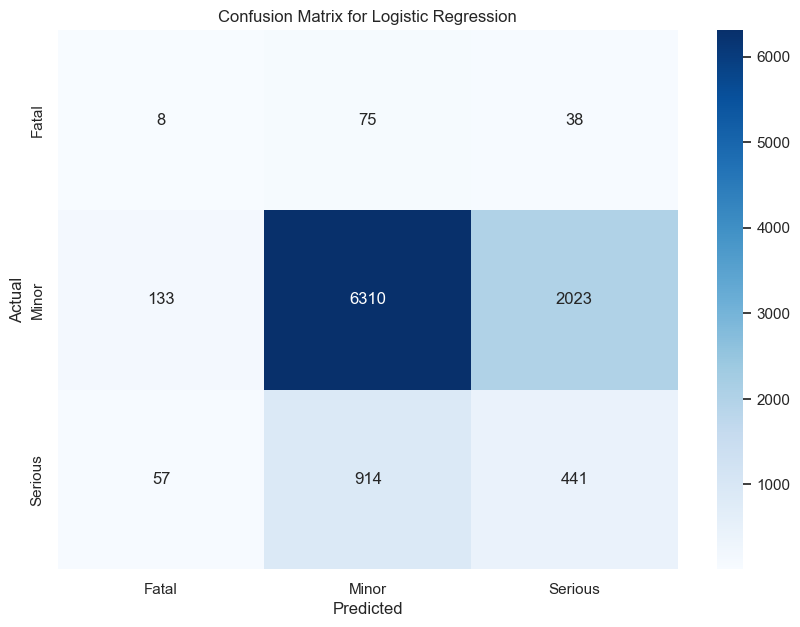

--------------------------------------------------

--- Evaluation for: Random Forest ---
Classification Report:
              precision    recall  f1-score   support

       Fatal       0.04      0.15      0.07       121
       Minor       0.87      0.77      0.82      8466
     Serious       0.21      0.31      0.25      1412

    accuracy                           0.70      9999
   macro avg       0.38      0.41      0.38      9999
weighted avg       0.77      0.70      0.73      9999



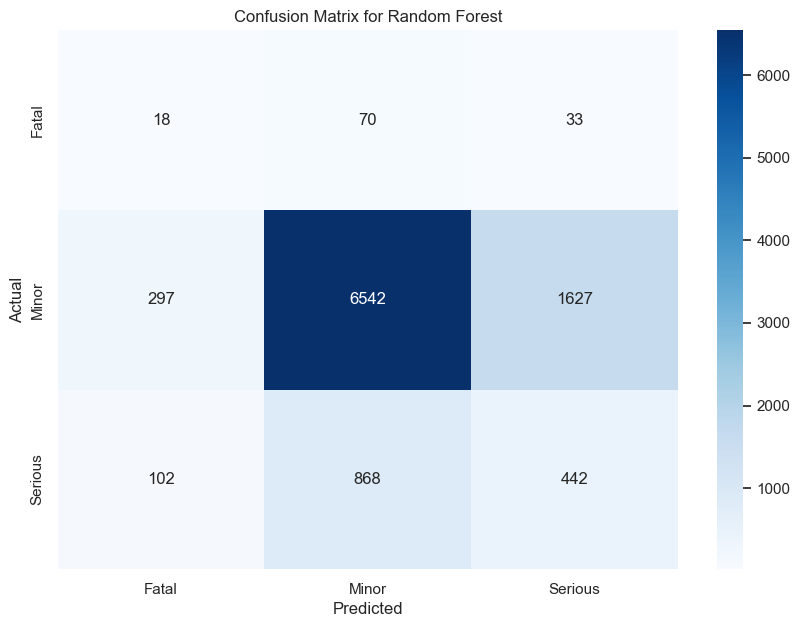

--------------------------------------------------

--- Evaluation for: LightGBM (Tuned) ---
Classification Report:
              precision    recall  f1-score   support

       Fatal       0.05      0.04      0.04       121
       Minor       0.86      0.87      0.87      8466
     Serious       0.21      0.19      0.20      1412

    accuracy                           0.77      9999
   macro avg       0.37      0.37      0.37      9999
weighted avg       0.76      0.77      0.76      9999



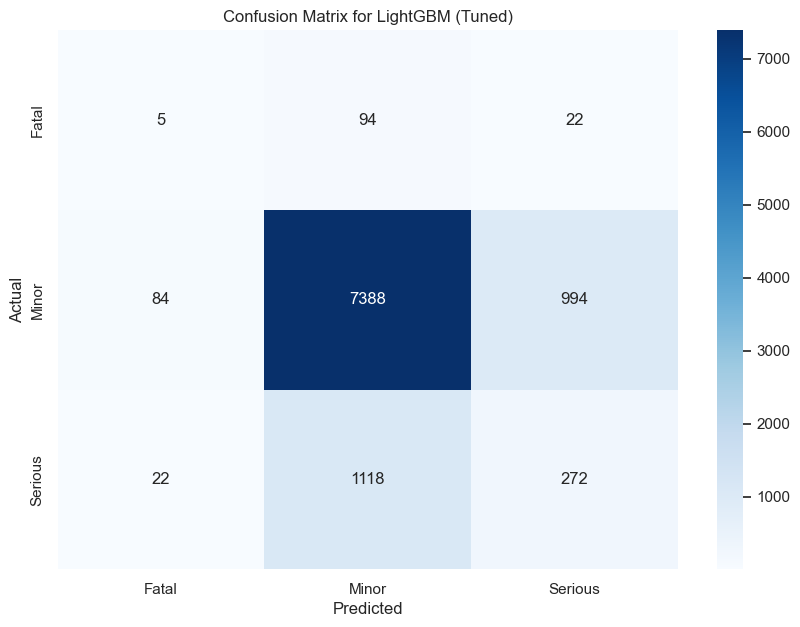

--------------------------------------------------



In [15]:
# --- Evaluate each trained model ---

for name, model in trained_models.items():
    print(f"--- Evaluation for: {name} ---")
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Print the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    # Display the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print("-" * 50 + "\n")